# TRUE COLOR IMAGE CREATER

In [38]:
from PIL import Image
import rasterio
import numpy as np

def convert_singleband_tif_to_jpg(input_path, output_path, stretch=True):
    # Read the single-band TIFF file
    with rasterio.open(input_path) as src:
        band = src.read(1)  # Read the first (and only) band

        # Normalize to 0-255 for visualization
        if stretch:
            band = band.astype(np.float32)
            band = 255 * (band - band.min()) / (band.max() - band.min() + 1e-6)
        
        band = np.clip(band, 0, 255).astype(np.uint8)

    # Convert to grayscale PIL image
    img = Image.fromarray(band, mode='L')

    # Save as JPEG
    img.save(output_path, format='JPEG', quality=95)
    print(f"Saved: {output_path}")

# Example usage
convert_singleband_tif_to_jpg('Blue - GOA.tif', 'Blue_GOA_2024.jpg')


Saved: Blue_GOA_2024.jpg


In [39]:
from PIL import Image
import rasterio
import numpy as np

def convert_singleband_tif_to_jpg(input_path, output_path, stretch=True):
    # Read the single-band TIFF file
    with rasterio.open(input_path) as src:
        band = src.read(1)  # Read the first (and only) band

        # Normalize to 0-255 for visualization
        if stretch:
            band = band.astype(np.float32)
            band = 255 * (band - band.min()) / (band.max() - band.min() + 1e-6)
        
        band = np.clip(band, 0, 255).astype(np.uint8)

    # Convert to grayscale PIL image
    img = Image.fromarray(band, mode='L')

    # Save as JPEG
    img.save(output_path, format='JPEG', quality=95)
    print(f"Saved: {output_path}")

# Example usage
convert_singleband_tif_to_jpg('Red - GOA.tif', 'Red_GOA_2024.jpg')


Saved: Red_GOA_2024.jpg


In [40]:
from PIL import Image
import rasterio
import numpy as np

def convert_singleband_tif_to_jpg(input_path, output_path, stretch=True):
    # Read the single-band TIFF file
    with rasterio.open(input_path) as src:
        band = src.read(1)  # Read the first (and only) band

        # Normalize to 0-255 for visualization
        if stretch:
            band = band.astype(np.float32)
            band = 255 * (band - band.min()) / (band.max() - band.min() + 1e-6)
        
        band = np.clip(band, 0, 255).astype(np.uint8)

    # Convert to grayscale PIL image
    img = Image.fromarray(band, mode='L')

    # Save as JPEG
    img.save(output_path, format='JPEG', quality=95)
    print(f"Saved: {output_path}")

# Example usage
convert_singleband_tif_to_jpg('Green - GOA.tif', 'Gree_GOA_2024.jpg')


Saved: Gree_GOA_2024.jpg


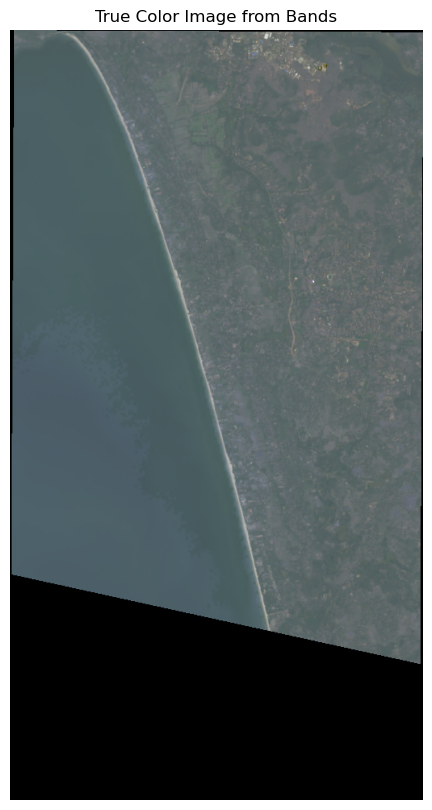

In [41]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the individual band images (ensure they are the same dimensions)
red = Image.open('Red_GOA_2024.jpg').convert('L')   # Band 4
green = Image.open('Gree_GOA_2024.jpg').convert('L') # Band 3
blue = Image.open('Blue_GOA_2024.jpg').convert('L')  # Band 2

# Convert images to numpy arrays
red_array = np.array(red)
green_array = np.array(green)
blue_array = np.array(blue)

# Stack into an RGB image (ensure shape is H x W)
rgb_array = np.stack((red_array, green_array, blue_array), axis=-1)

# Optional: normalize to 0–255 if needed
# rgb_array = (rgb_array / rgb_array.max()) * 255
# rgb_array = rgb_array.astype(np.uint8)

# Display using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(rgb_array)
plt.title('True Color Image from Bands')
plt.axis('off')
plt.show()

# Save the image (optional)
Image.fromarray(rgb_array).save('GOA_2024.jpg')


# PROCESSING>>>>

In [28]:
import os
import cv2
import numpy as np

# === SET THESE PATHS ===
input_rgb_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\TRUE COLOR VIZAG"
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\GREEN VIZAG"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\NIR VIZAG"

# Create output folders if they don't exist
os.makedirs(green_folder, exist_ok=True)
os.makedirs(nir_folder, exist_ok=True)

# Resize for consistency (optional)
IMG_SIZE = 256

# Sort files and assign years from 2015 to 2024
image_files = sorted([
    f for f in os.listdir(input_rgb_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

years = list(range(2015, 2015 + len(image_files)))

for filename, year in zip(image_files, years):
    path = os.path.join(input_rgb_folder, filename)
    image = cv2.imread(path)

    if image is None:
        print(f"Skipping {filename} (unable to read).")
        continue

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Extract Green band
    green_band = image[:, :, 1]

    # Estimate NIR using RGB approximation
    nir_band = (0.3 * image[:, :, 2] + 0.3 * image[:, :, 1] + 0.4 * image[:, :, 0]).astype(np.uint8)

    # Save with new consistent filenames
    green_filename = f"rameshwaram_{year}_green.jpg"
    nir_filename = f"rameshwaram_{year}_nir.jpg"

    cv2.imwrite(os.path.join(green_folder, green_filename), green_band)
    cv2.imwrite(os.path.join(nir_folder, nir_filename), nir_band)

    print(f"Saved Green: {green_filename}, NIR: {nir_filename}")


Saved Green: rameshwaram_2015_green.jpg, NIR: rameshwaram_2015_nir.jpg
Saved Green: rameshwaram_2016_green.jpg, NIR: rameshwaram_2016_nir.jpg
Saved Green: rameshwaram_2017_green.jpg, NIR: rameshwaram_2017_nir.jpg
Saved Green: rameshwaram_2018_green.jpg, NIR: rameshwaram_2018_nir.jpg


In [29]:
import os
import cv2
import numpy as np

# === PATHS ===
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\GREEN VIZAG"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\NIR VIZAG"
output_mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG"

os.makedirs(output_mask_folder, exist_ok=True)

threshold = 0.0
IMG_SIZE = 256

def compute_ndwi(green, nir, cloud_mask):
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi[cloud_mask] = -1  # Set NDWI of cloud pixels to very low so they're classified as non-water
    return np.clip(ndwi, -1, 1)

def classify_shoreline(ndwi_map, threshold=0.0):
    return (ndwi_map > threshold).astype(np.uint8) * 255

green_files = sorted([f for f in os.listdir(green_folder) if f.endswith(".jpg")])
nir_files = sorted([f for f in os.listdir(nir_folder) if f.endswith(".jpg")])

if len(green_files) != len(nir_files):
    raise ValueError("Mismatch in number of Green and NIR images!")

for green_file, nir_file in zip(green_files, nir_files):
    green_path = os.path.join(green_folder, green_file)
    nir_path = os.path.join(nir_folder, nir_file)

    green = cv2.imread(green_path, cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None:
        print(f"Skipping {green_file} or {nir_file}")
        continue

    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))

    # Remove cloud pixels: detect nearly white regions in Green band
    # Adjust value if needed (240 works for most white regions)
    cloud_mask = (green > 240)

    # Apply smoothing to reduce noisy classification
    green = cv2.GaussianBlur(green, (5, 5), 0)
    nir = cv2.GaussianBlur(nir, (5, 5), 0)

    ndwi = compute_ndwi(green, nir, cloud_mask)
    shoreline_mask = classify_shoreline(ndwi, threshold)

    base_name = green_file.replace("_green.jpg", "")
    mask_path = os.path.join(output_mask_folder, f"{base_name}_shoreline_mask.jpg")
    cv2.imwrite(mask_path, shoreline_mask)

    print(f"Saved clean mask: {mask_path}")


Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\rameshwaram_2015_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\rameshwaram_2016_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\rameshwaram_2017_shoreline_mask.jpg
Saved clean mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\rameshwaram_2018_shoreline_mask.jpg


# NDWI

Epoch 1/20
1/1 [==============================] - 7s 7s/step - loss: 0.6912 - accuracy: 0.5194 - val_loss: 0.6751 - val_accuracy: 0.5893
Epoch 2/20
1/1 [==============================] - 2s 2s/step - loss: 0.6876 - accuracy: 0.5222 - val_loss: 0.6663 - val_accuracy: 0.5931
Epoch 3/20
1/1 [==============================] - 2s 2s/step - loss: 0.6862 - accuracy: 0.5233 - val_loss: 0.6577 - val_accuracy: 0.5931
Epoch 4/20
1/1 [==============================] - 1s 1s/step - loss: 0.6859 - accuracy: 0.5233 - val_loss: 0.6565 - val_accuracy: 0.5931
Epoch 5/20
1/1 [==============================] - 2s 2s/step - loss: 0.6852 - accuracy: 0.5233 - val_loss: 0.6582 - val_accuracy: 0.5931
Epoch 6/20
1/1 [==============================] - 2s 2s/step - loss: 0.6844 - accuracy: 0.5233 - val_loss: 0.6604 - val_accuracy: 0.5967
Epoch 7/20
1/1 [==============================] - 2s 2s/step - loss: 0.6839 - accuracy: 0.5253 - val_loss: 0.6594 - val_accuracy: 0.5970
Epoch 8/20
1/1 [=========================

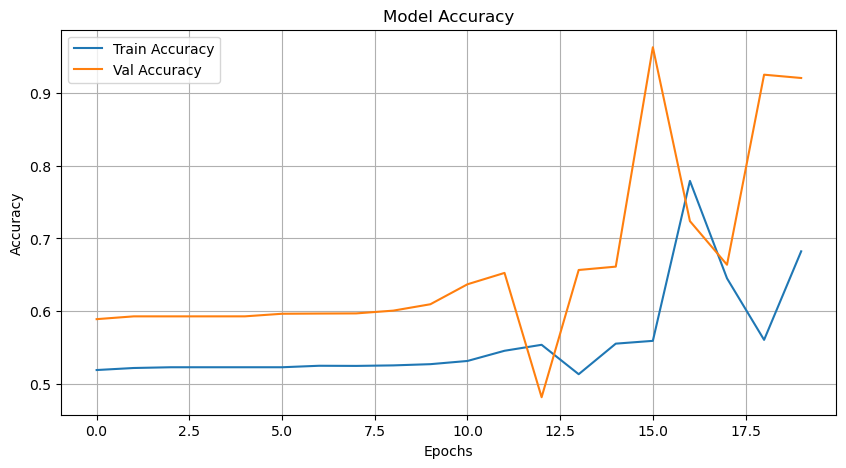

In [30]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# === Set Paths ===
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\GREEN VIZAG"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\NIR VIZAG"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG"

IMG_SIZE = 256

def compute_ndwi(green, nir):
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    return np.clip(ndwi, -1, 1)

# === Load NDWI Images and Corresponding Masks ===
X, Y = [], []

green_files = sorted([f for f in os.listdir(green_folder) if f.endswith('.jpg')])
nir_files = sorted([f for f in os.listdir(nir_folder) if f.endswith('.jpg')])
mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith('.jpg')])

for gf, nf, mf in zip(green_files, nir_files, mask_files):
    green = cv2.imread(os.path.join(green_folder, gf), cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(os.path.join(nir_folder, nf), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_folder, mf), cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None or mask is None:
        print(f"Skipping {gf}, {nf}, or {mf}")
        continue

    # Resize for uniformity
    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    ndwi = compute_ndwi(green, nir)
    ndwi = (ndwi + 1) / 2  # Normalize to 0-1
    ndwi = np.expand_dims(ndwi, axis=-1)  # Shape: (H, W, 1)
    mask = (mask > 127).astype(np.float32)  # Binary
    mask = np.expand_dims(mask, axis=-1)  # Shape: (H, W, 1)

    X.append(ndwi)
    Y.append(mask)

X = np.array(X)
Y = np.array(Y)

# === Split Dataset ===
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# === Simple U-Net Model ===
def get_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    u1 = layers.UpSampling2D()(b)
    concat1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    concat2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(concat2)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = get_unet((IMG_SIZE, IMG_SIZE, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# === Train ===
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=4)

# === Plot Accuracy ===
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [32]:
import os
import cv2
import numpy as np

# === Set your folder paths ===
green_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\GREEN VIZAG"
nir_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\NIR VIZAG"
output_ndwi_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG"

# Create output folder if it doesn't exist
os.makedirs(output_ndwi_folder, exist_ok=True)

# Resize size for consistency (optional)
IMG_SIZE = 256

# Get sorted file lists
green_files = sorted([f for f in os.listdir(green_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
nir_files = sorted([f for f in os.listdir(nir_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Check equal number of files
if len(green_files) != len(nir_files):
    raise ValueError("Mismatch between number of green and NIR images.")

# Loop through each pair and compute NDWI
for green_file, nir_file in zip(green_files, nir_files):
    green_path = os.path.join(green_folder, green_file)
    nir_path = os.path.join(nir_folder, nir_file)

    green = cv2.imread(green_path, cv2.IMREAD_GRAYSCALE)
    nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE)

    if green is None or nir is None:
        print(f"Skipping: {green_file} or {nir_file} not readable.")
        continue

    # Resize for consistency
    green = cv2.resize(green, (IMG_SIZE, IMG_SIZE))
    nir = cv2.resize(nir, (IMG_SIZE, IMG_SIZE))

    # Compute NDWI
    green = green.astype(np.float32)
    nir = nir.astype(np.float32)
    ndwi = (green - nir) / (green + nir + 1e-10)
    ndwi = np.clip(ndwi, -1, 1)

    # Normalize to 0-255 for saving
    ndwi_normalized = ((ndwi + 1) / 2 * 255).astype(np.uint8)

    # Save the NDWI grayscale image
    base_name = os.path.splitext(green_file)[0].replace('_green', '')
    output_path = os.path.join(output_ndwi_folder, f"{base_name}_ndwi.jpg")
    cv2.imwrite(output_path, ndwi_normalized)

    print(f"Saved: {output_path}")


Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG\rameshwaram_2015_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG\rameshwaram_2016_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG\rameshwaram_2017_ndwi.jpg
Saved: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG\rameshwaram_2018_ndwi.jpg


## Training using U-NET

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_11 (Conv2D)             (None, 256, 256, 16  160         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_12 (Conv2D)             (None, 256, 256, 16  2320        ['conv2d_11[0][0]']              
                                )                                                           

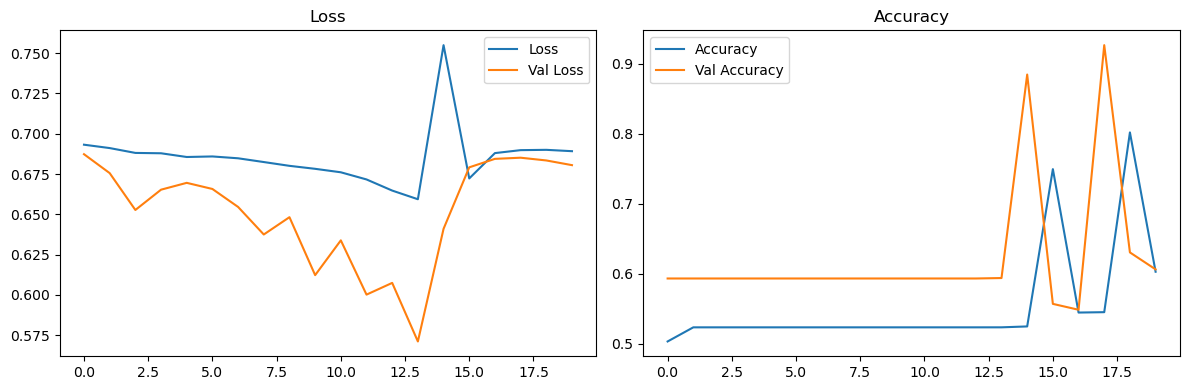

In [33]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# === SET FOLDERS ===
ndwi_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\COMPUTED VIZAG"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG"

IMG_SIZE = 256

# === LOAD IMAGES ===
def load_images(folder):
    images = []
    for file in sorted(os.listdir(folder)):
        if file.lower().endswith((".jpg", ".png")):
            img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0
            images.append(img)
    return np.expand_dims(np.array(images), axis=-1)

X = load_images(ndwi_folder)  # NDWI grayscale inputs
y = load_images(mask_folder)  # Binary shoreline masks
y = (y > 0.5).astype(np.float32)  # Ensure masks are binary

# === TRAIN-TEST SPLIT ===
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# === U-NET MODEL ===
def unet_model(input_shape=(256, 256, 1)):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # Decoder
    u3 = layers.UpSampling2D()(b)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c6)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = unet_model()
model.summary()

# === TRAINING ===
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=4)

# === PLOTS ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title("Accuracy")

plt.tight_layout()
plt.show()


# Canny edge

In [35]:
import os
import cv2
import numpy as np

# === SET PATHS ===
input_rgb_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\TRUE COLOR VIZAG"  # Folder with RGB images
output_mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG"  # Folder to save edge masks

# Create output folder if it doesn't exist
os.makedirs(output_mask_folder, exist_ok=True)

# Resize size for consistency
IMG_SIZE = 256

# === Process All Images ===
for filename in sorted(os.listdir(input_rgb_folder)):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    image_path = os.path.join(input_rgb_folder, filename)
    image = cv2.imread(image_path)

    if image is None:
        print(f"Skipping {filename} (unreadable).")
        continue

    # Resize image
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur (optional)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Otsu's thresholding to get optimal threshold value
    otsu_val, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Compute Canny thresholds based on Otsu
    lower_thresh = 0.5 * otsu_val
    upper_thresh = otsu_val

    # Apply Canny edge detection
    edges = cv2.Canny(blurred, lower_thresh, upper_thresh)

    # Save the mask
    base_name = os.path.splitext(filename)[0]
    output_path = os.path.join(output_mask_folder, f"{base_name}_canny.jpg")
    cv2.imwrite(output_path, edges)

    print(f"Saved mask: {output_path}")


Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_1991_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2001_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2011_canny.jpg
Saved mask: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2018_canny.jpg


## Training using U-NET 

Epoch 1/20 | Train Loss: 0.7505 | Val Loss: 0.7620 | Train Acc: 0.2589 | Val Acc: 0.0201
Epoch 2/20 | Train Loss: 0.6683 | Val Loss: 0.7009 | Train Acc: 0.5568 | Val Acc: 0.0211
Epoch 3/20 | Train Loss: 0.6106 | Val Loss: 0.6312 | Train Acc: 0.7494 | Val Acc: 0.9316
Epoch 4/20 | Train Loss: 0.5609 | Val Loss: 0.5787 | Train Acc: 0.8563 | Val Acc: 0.9319
Epoch 5/20 | Train Loss: 0.5232 | Val Loss: 0.5621 | Train Acc: 0.8676 | Val Acc: 0.9319
Epoch 6/20 | Train Loss: 0.5151 | Val Loss: 0.5395 | Train Acc: 0.8729 | Val Acc: 0.9319
Epoch 7/20 | Train Loss: 0.4681 | Val Loss: 0.4790 | Train Acc: 0.8756 | Val Acc: 0.9319
Epoch 8/20 | Train Loss: 0.4448 | Val Loss: 0.4322 | Train Acc: 0.8772 | Val Acc: 0.9319
Epoch 9/20 | Train Loss: 0.4076 | Val Loss: 0.3942 | Train Acc: 0.8859 | Val Acc: 0.9319
Epoch 10/20 | Train Loss: 0.4290 | Val Loss: 0.3796 | Train Acc: 0.8954 | Val Acc: 0.9319
Epoch 11/20 | Train Loss: 0.3698 | Val Loss: 0.3325 | Train Acc: 0.8837 | Val Acc: 0.9319
Epoch 12/20 | Train

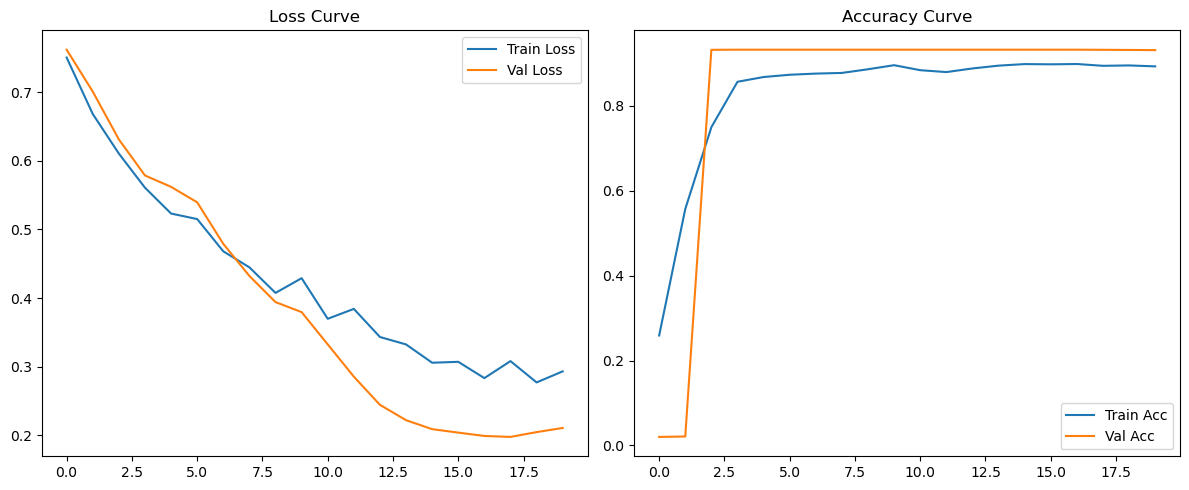

In [2]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# === SET THESE PATHS ===
input_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\NDWI rameshwaram\TRUE COLOR rameshwaram"
mask_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\NDWI rameshwaram\TRUE COLOR rameshwaram\CANNY EDGE MASK"
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Dataset
class ShorelineDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.FloatTensor(img), torch.FloatTensor(mask)

# Load file paths
input_files = sorted([os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(".jpg")])
mask_files = sorted([os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith(".jpg")])

# Train-test split
train_inputs, val_inputs, train_masks, val_masks = train_test_split(input_files, mask_files, test_size=0.2, random_state=42)
train_dataset = ShorelineDataset(train_inputs, train_masks)
val_dataset = ShorelineDataset(val_inputs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Simple U-Net
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(1, 64)
        self.enc2 = CBR(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.dec1 = CBR(128, 64)
        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool(x1)
        x3 = self.enc2(x2)
        x4 = self.pool(x3)

        x5 = torch.nn.functional.interpolate(x4, scale_factor=2, mode='bilinear', align_corners=False)
        x6 = self.dec1(x5)
        x7 = torch.nn.functional.interpolate(x6, scale_factor=2, mode='bilinear', align_corners=False)
        out = self.final(x7)
        return torch.sigmoid(out)

# Initialize model, loss, optimizer
model = UNet().to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += ((preds > 0.5) == masks).float().mean().item()

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(train_correct / len(train_loader))

    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item()
            val_correct += ((preds > 0.5) == masks).float().mean().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / len(val_loader))

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()


# Comparision

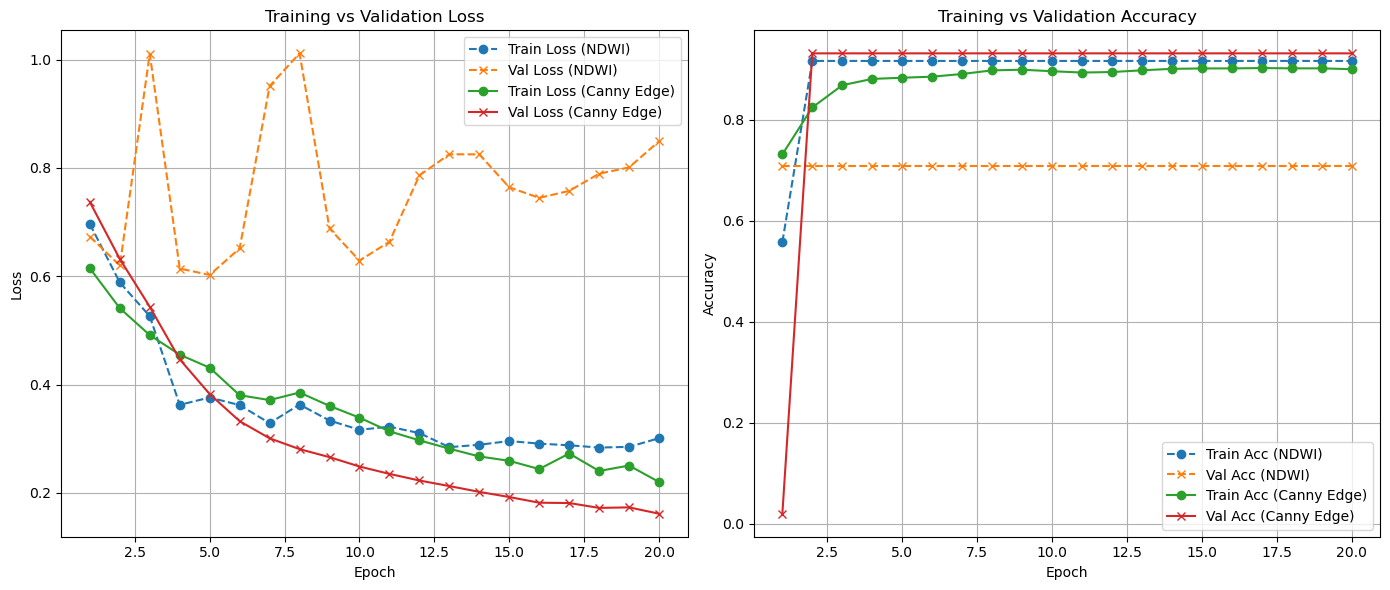

In [38]:
import matplotlib.pyplot as plt

# === First Log (Keras-style format) ===
loss_1 = [0.6964, 0.5885, 0.5262, 0.3627, 0.3762, 0.3622, 0.3288, 0.3632, 0.3337, 0.3166,
          0.3223, 0.3105, 0.2845, 0.2890, 0.2958, 0.2911, 0.2880, 0.2838, 0.2851, 0.3011]
val_loss_1 = [0.6734, 0.6199, 1.0108, 0.6143, 0.6024, 0.6515, 0.9510, 1.0115, 0.6883, 0.6288,
              0.6638, 0.7861, 0.8252, 0.8250, 0.7642, 0.7447, 0.7576, 0.7894, 0.8009, 0.8492]

acc_1 = [0.5581, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169,
         0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169, 0.9169]
val_acc_1 = [0.7079] * 20

# === Second Log (Custom format) ===
loss_2 = [0.6147, 0.5410, 0.4914, 0.4553, 0.4312, 0.3804, 0.3715, 0.3854, 0.3607, 0.3390,
          0.3138, 0.2971, 0.2817, 0.2674, 0.2593, 0.2441, 0.2728, 0.2406, 0.2506, 0.2202]
val_loss_2 = [0.7370, 0.6319, 0.5437, 0.4467, 0.3825, 0.3325, 0.3009, 0.2809, 0.2661, 0.2488,
              0.2352, 0.2230, 0.2127, 0.2020, 0.1925, 0.1820, 0.1814, 0.1724, 0.1734, 0.1617]

acc_2 = [0.7318, 0.8248, 0.8688, 0.8813, 0.8836, 0.8857, 0.8910, 0.8982, 0.8995, 0.8965,
         0.8939, 0.8949, 0.8983, 0.9012, 0.9020, 0.9021, 0.9028, 0.9022, 0.9022, 0.9005]
val_acc_2 = [0.0201] + [0.9319]*19

# === Plotting ===
epochs = list(range(1, 21))

plt.figure(figsize=(14, 6))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_1, label='Train Loss (NDWI)', marker='o', linestyle = '--')
plt.plot(epochs, val_loss_1, label='Val Loss (NDWI)', marker='x', linestyle = '--')
plt.plot(epochs, loss_2, label='Train Loss (Canny Edge)', marker='o')
plt.plot(epochs, val_loss_2, label='Val Loss (Canny Edge)', marker='x')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# --- ACCURACY ---
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_1, label='Train Acc (NDWI)', marker='o', linestyle = '--')
plt.plot(epochs, val_acc_1, label='Val Acc (NDWI)', marker='x', linestyle = '--')
plt.plot(epochs, acc_2, label='Train Acc (Canny Edge)', marker='o')
plt.plot(epochs, val_acc_2, label='Val Acc (Canny Edge)', marker='x')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# VIZAG comparision

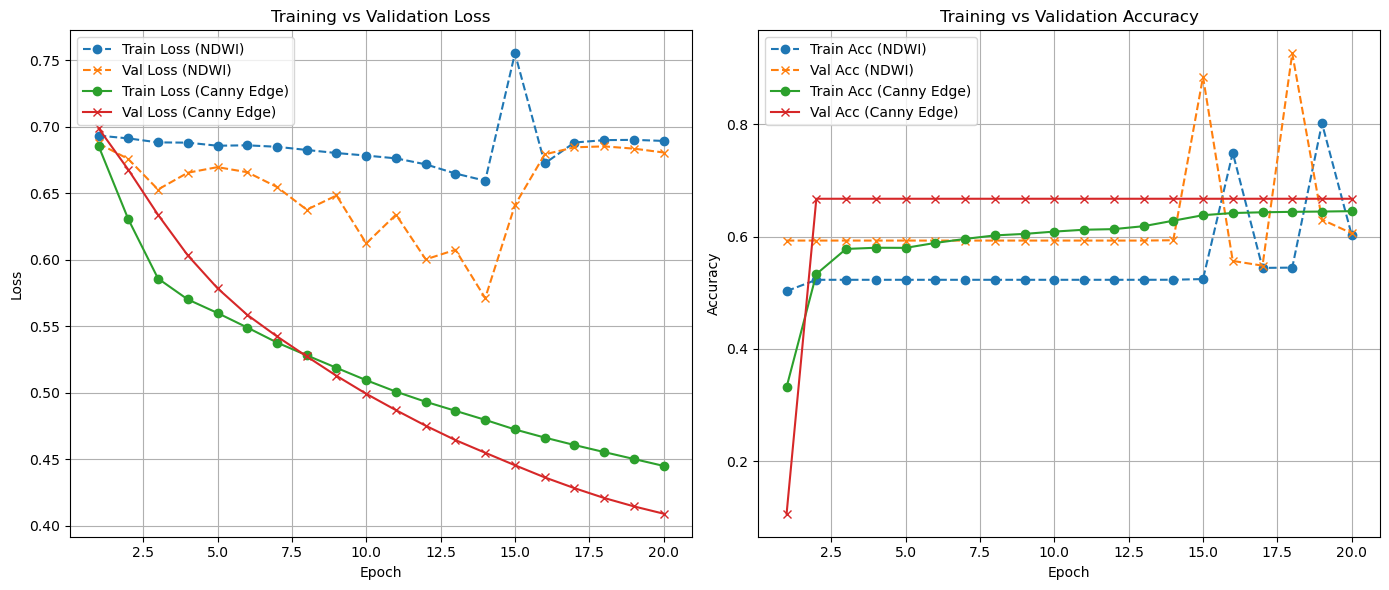

In [40]:
import matplotlib.pyplot as plt

# === Method 1 Logs (Keras-style format) ===
loss_1 = [0.6932, 0.6911, 0.6881, 0.6879, 0.6856, 0.6859, 0.6848, 0.6824, 0.6801, 0.6782,
          0.6761, 0.6716, 0.6647, 0.6593, 0.7550, 0.6723, 0.6880, 0.6898, 0.6900, 0.6892]
val_loss_1 = [0.6873, 0.6756, 0.6527, 0.6653, 0.6695, 0.6657, 0.6546, 0.6375, 0.6482, 0.6122,
              0.6338, 0.6002, 0.6074, 0.5711, 0.6410, 0.6791, 0.6844, 0.6851, 0.6834, 0.6805]

acc_1 = [0.5031, 0.5232, 0.5232, 0.5232, 0.5232, 0.5232, 0.5232, 0.5232, 0.5232, 0.5232,
         0.5232, 0.5232, 0.5232, 0.5233, 0.5245, 0.7495, 0.5444, 0.5449, 0.8019, 0.6027]
val_acc_1 = [0.5931, 0.5931, 0.5931, 0.5931, 0.5931, 0.5931, 0.5931, 0.5931, 0.5931, 0.5931,
             0.5931, 0.5931, 0.5931, 0.5937, 0.8847, 0.5568, 0.5484, 0.9267, 0.6304, 0.6061]

# === Method 2 Logs (Custom format) ===
loss_2 = [0.6855, 0.6304, 0.5858, 0.5701, 0.5599, 0.5490, 0.5377, 0.5281, 0.5187, 0.5094,
          0.5008, 0.4932, 0.4864, 0.4796, 0.4724, 0.4663, 0.4607, 0.4554, 0.4502, 0.4450]
val_loss_2 = [0.6987, 0.6676, 0.6337, 0.6032, 0.5785, 0.5585, 0.5423, 0.5273, 0.5127, 0.4992,
              0.4869, 0.4752, 0.4644, 0.4549, 0.4455, 0.4364, 0.4283, 0.4209, 0.4146, 0.4091]

acc_2 = [0.3321, 0.5334, 0.5782, 0.5803, 0.5801, 0.5889, 0.5960, 0.6023, 0.6050, 0.6091,
         0.6124, 0.6135, 0.6187, 0.6285, 0.6383, 0.6422, 0.6435, 0.6443, 0.6448, 0.6455]
val_acc_2 = [0.1064, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676,
             0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676, 0.6676]

# === Plotting ===
epochs = list(range(1, 21))

plt.figure(figsize=(14, 6))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_1, label='Train Loss (NDWI)', marker='o', linestyle='--')
plt.plot(epochs, val_loss_1, label='Val Loss (NDWI)', marker='x', linestyle='--')
plt.plot(epochs, loss_2, label='Train Loss (Canny Edge)', marker='o')
plt.plot(epochs, val_loss_2, label='Val Loss (Canny Edge)', marker='x')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# --- ACCURACY ---
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_1, label='Train Acc (NDWI)', marker='o', linestyle='--')
plt.plot(epochs, val_acc_1, label='Val Acc (NDWI)', marker='x', linestyle='--')
plt.plot(epochs, acc_2, label='Train Acc (Canny Edge)', marker='o')
plt.plot(epochs, val_acc_2, label='Val Acc (Canny Edge)', marker='x')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [41]:
import cv2
import numpy as np
import os
from scipy.spatial.distance import directed_hausdorff
from skimage.metrics import hausdorff_distance

def extract_coordinates(mask):
    """
    Extracts (y, x) pixel coordinates from a binary mask where pixels are 255.
    """
    coords = np.column_stack(np.where(mask == 255))
    return coords

def calculate_hausdorff(mask1, mask2):
    """
    Calculates directed and symmetric Hausdorff distances and returns pixel coordinates.
    """
    coords1 = extract_coordinates(mask1)
    coords2 = extract_coordinates(mask2)

    d_forward = directed_hausdorff(coords1, coords2)[0]
    d_backward = directed_hausdorff(coords2, coords1)[0]
    d_symmetric = max(d_forward, d_backward)
    d_skimage = hausdorff_distance(mask1, mask2)

    return d_forward, d_backward, d_symmetric, d_skimage, coords1, coords2

def load_binary_mask(path):
    """
    Loads an image as grayscale and thresholds it to binary (0 and 255).
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    return binary

def process_folder(gt_folder, pred_folder):
    """
    Processes all matching images in the GT and predicted folders.
    """
    gt_files = sorted(os.listdir(gt_folder))
    pred_files = sorted(os.listdir(pred_folder))

    for filename in gt_files:
        if filename in pred_files:
            gt_path = os.path.join(gt_folder, filename)
            pred_path = os.path.join(pred_folder, filename)

            try:
                gt_mask = load_binary_mask(gt_path)
                pred_mask = load_binary_mask(pred_path)

                d_fwd, d_bwd, d_sym, d_skimg, coords_gt, coords_pred = calculate_hausdorff(gt_mask, pred_mask)

                print(f"\n--- {filename} ---")
                print(f"Directed GT→Pred: {d_fwd:.2f}")
                print(f"Directed Pred→GT: {d_bwd:.2f}")
                print(f"Symmetric Hausdorff: {d_sym:.2f}")
                print(f"Skimage Hausdorff : {d_skimg:.2f}")
                print(f"GT pixel coordinates (sample): {coords_gt[:3]}")
                print(f"Pred pixel coordinates (sample): {coords_pred[:3]}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")
        else:
            print(f"Warning: No prediction found for {filename}")

# === Set your folders here ===
ground_truth_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\TRUE COLOR VIZAG"
predicted_masks_folder =  r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG"

# === Run the processing ===
process_folder(ground_truth_folder, predicted_masks_folder)


Percentage Shoreline Change: 0.61%


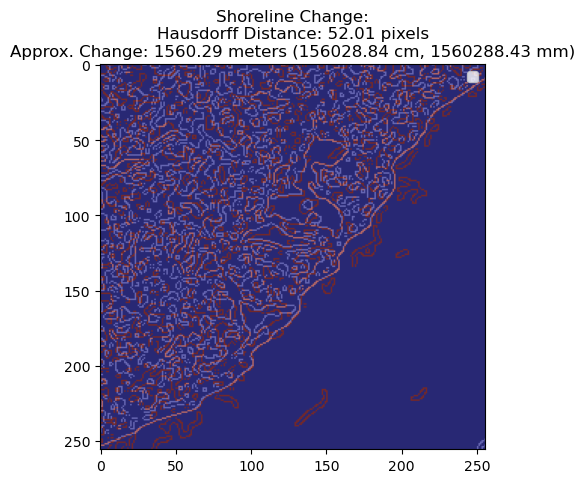

In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from shapely.geometry import LineString
from scipy.spatial.distance import directed_hausdorff

# Function to read an image in grayscale
def read_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not open {image_path}")
    return image

# Function to extract shorelines using edge detection
def extract_shoreline(image_path):
    image = read_image(image_path)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Apply Otsu's thresholding to separate land and water
    thresh = threshold_otsu(blurred)
    binary_mask = (blurred > thresh).astype(np.uint8) * 255

    # Detect edges using Canny
    edges = cv2.Canny(binary_mask, 50, 150)

    return edges

# Function to compute shoreline change using Hausdorff Distance
def shoreline_change(shoreline1, shoreline2, resolution_m_per_pixel):
    # Convert shorelines to coordinate lists
    coords1 = np.column_stack(np.where(shoreline1 > 0))
    coords2 = np.column_stack(np.where(shoreline2 > 0))

    # Convert to LineString objects (for visualization)
    line1 = LineString(coords1)
    line2 = LineString(coords2)

    # Compute Hausdorff Distance (max shoreline shift in pixels)
    hausdorff_dist_pixels = directed_hausdorff(coords1, coords2)[0]

    # Convert to meters, cm, and mm
    hausdorff_dist_meters = hausdorff_dist_pixels * resolution_m_per_pixel
    hausdorff_dist_cm = hausdorff_dist_meters * 100
    hausdorff_dist_mm = hausdorff_dist_meters * 1000

    return hausdorff_dist_pixels, hausdorff_dist_meters, hausdorff_dist_cm, hausdorff_dist_mm, line1, line2

# Load images from different years
image_2010 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_1991_canny.jpg"
image_2020 = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2018_canny.jpg"

# Define spatial resolution (meters per pixel)
resolution_m_per_pixel = 30  # Change this based on your image source

# Extract shorelines
shoreline_2010 = extract_shoreline(image_2010)
shoreline_2020 = extract_shoreline(image_2020)

# Compute shoreline change
distance_pixels, distance_meters, distance_cm, distance_mm, line1, line2 = shoreline_change(
    shoreline_2010, shoreline_2020, resolution_m_per_pixel
)
# Calculate percentage change relative to 2010 shoreline length
baseline_length_pixels = len(np.column_stack(np.where(shoreline_2010 > 0)))
percentage_change = (distance_pixels / baseline_length_pixels) * 100

# Print percentage change
print(f"Percentage Shoreline Change: {percentage_change:.2f}%")


# Plot the results
plt.figure(figsize=(10, 5))
plt.imshow(shoreline_2010, cmap='gray', alpha=0.6)
plt.imshow(shoreline_2020, cmap='jet', alpha=0.6)
plt.title(f"Shoreline Change:\n"
          f"Hausdorff Distance: {distance_pixels:.2f} pixels\n"
          f"Approx. Change: {distance_meters:.2f} meters ({distance_cm:.2f} cm, {distance_mm:.2f} mm)")
plt.legend(["2010 Shoreline", "2020 Shoreline"])
plt.show()


1991-2001 Shoreline Shift: 4542.00 meters
2001-2011 Shoreline Shift: 4566.02 meters
2011-2018 Shoreline Shift: 1771.02 meters
Total Shoreline Shift: 10879.04 meters
End Point Rate (EPR): 402.93 meters/year
Linear Regression Rate (LRR): 412.18 meters/year


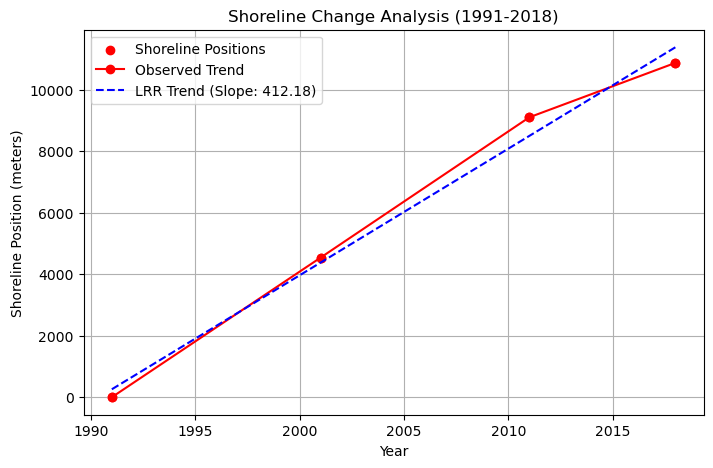

In [46]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.spatial.distance import directed_hausdorff

# Define images and corresponding years manually
images_data = {
    1991: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_1991_canny.jpg",
    2001: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2001_canny.jpg",
    2011: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2011_canny.jpg",
    2018: r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\Canny Edge VIZAG\True_Color_Image_2018_canny.jpg",
}

# Load images manually
images = {}
for year, image_path in images_data.items():
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is not None:
        images[year] = image
    else:
        print(f"Warning: Image for {year} not found!")

# Function to apply simple thresholding for shoreline extraction
def extract_shoreline(image):
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shoreline = np.vstack([c.squeeze() for c in contours if len(c) > 1])  # Stack all shoreline points
    return shoreline

# Extract shorelines for manually inputted images
shorelines = {year: extract_shoreline(images[year]) for year in images}

# Compute Hausdorff Distance between consecutive years
hausdorff_distances = []
shoreline_shifts = []
pixel_to_meter = 30  # Resolution assumption

years = sorted(images.keys())  # Sort years in ascending order

for i in range(len(years) - 1):
    year1, year2 = years[i], years[i + 1]
    if year1 in shorelines and year2 in shorelines:
        hausdorff_dist = max(directed_hausdorff(shorelines[year1], shorelines[year2])[0],
                             directed_hausdorff(shorelines[year2], shorelines[year1])[0])
        hausdorff_distances.append(hausdorff_dist)
        shoreline_shifts.append(hausdorff_dist * pixel_to_meter)
        print(f"{year1}-{year2} Shoreline Shift: {shoreline_shifts[-1]:.2f} meters")

# **End Point Rate (EPR) Calculation**
total_years = years[-1] - years[0]
total_shift = sum(shoreline_shifts)  # Cumulative shift
EPR = total_shift / total_years  # meters per year

# **Linear Regression Rate (LRR) Calculation**
positions = np.cumsum([0] + shoreline_shifts)  # Accumulative positions
slope, intercept, r_value, p_value, std_err = linregress(years[:len(positions)], positions)
LRR = slope  # meters per year

# **Print Results**
print(f"Total Shoreline Shift: {total_shift:.2f} meters")
print(f"End Point Rate (EPR): {EPR:.2f} meters/year")
print(f"Linear Regression Rate (LRR): {LRR:.2f} meters/year")

# **Plot Shoreline Shift with Connected Line**
plt.figure(figsize=(8, 5))
plt.scatter(years[:len(positions)], positions, color='red', label='Shoreline Positions')
plt.plot(years[:len(positions)], positions, color='red', linestyle='-', marker='o', label='Observed Trend')  # Connect points
plt.plot(years[:len(positions)], slope * np.array(years[:len(positions)]) + intercept, 
         color='blue', linestyle='dashed', label=f'LRR Trend (Slope: {LRR:.2f})')

plt.xlabel("Year")
plt.ylabel("Shoreline Position (meters)")
plt.title(f"Shoreline Change Analysis ({years[0]}-{years[-1]})")
plt.legend()
plt.grid(True)
plt.show()

# NEW TESTING METHOD

In [2]:
import os
import cv2

def apply_canny_to_folder(input_folder, output_folder, low_threshold=50, high_threshold=150):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            # Read image in grayscale
            image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                print(f"Skipping {filename}, could not read image.")
                continue

            # Apply Canny edge detection
            edges = cv2.Canny(image, low_threshold, high_threshold)

            # Save the edge-detected image
            cv2.imwrite(output_path, edges)
            print(f"Saved Canny edge image: {output_path}")

# Example usage:
input_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\TRUE COLOR VIZAG"
output_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder"

apply_canny_to_folder(input_folder, output_folder)


Saved Canny edge image: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder\True_Color_Image_1991.jpg
Saved Canny edge image: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder\True_Color_Image_2001.jpg
Saved Canny edge image: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder\True_Color_Image_2011.jpg
Saved Canny edge image: C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder\True_Color_Image_2018.jpg


In [6]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from shapely.errors import TopologicalError

# Parameters
folder_path = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\VIZAG\MASK VIZAG\New folder"
resolution_m_per_pixel = 30  # meters/pixel
buffer_distance_m = 50

def read_mask(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read image: {path}")
    return img

def get_shoreline_coords(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    all_coords = []
    for contour in contours:
        for point in contour:
            y, x = point[0][1], point[0][0]
            all_coords.append((x, y))
    return all_coords

def create_buffered_line(coords, resolution_m_per_pixel, buffer_distance_m):
    if len(coords) < 2:
        raise ValueError("Not enough coordinates to form a line.")
    # Simplify coordinates by removing duplicates and noisy points
    simplified = [coords[0]]
    for pt in coords[1:]:
        if pt != simplified[-1]:
            simplified.append(pt)
    line = LineString(simplified)
    buffer_pixels = buffer_distance_m / resolution_m_per_pixel
    # Handle potential topological errors
    try:
        buffered_line = line.parallel_offset(buffer_pixels, side='left', join_style=2)
    except TopologicalError as e:
        raise ValueError(f"Topology error in buffering: {e}")
    return line, buffered_line

def plot_lines(mask, original, buffered, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(mask, cmap='gray')
    if isinstance(original, LineString):
        x, y = original.xy
        plt.plot(x, y, color='blue', label='Original Shoreline')
    if isinstance(buffered, LineString):
        x2, y2 = buffered.xy
        plt.plot(x2, y2, color='red', label='50m Parallel Line')
    plt.title(title)
    plt.legend()
    plt.show()

# Loop through all mask images
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        full_path = os.path.join(folder_path, filename)
        try:
            mask = read_mask(full_path)
            coords = get_shoreline_coords(mask)
            if coords:
                line, buffered_line = create_buffered_line(coords, resolution_m_per_pixel, buffer_distance_m)
                plot_lines(mask, line, buffered_line, f"File: {filename}")
            else:
                print(f"No contours found in {filename}")
        except Exception as e:
            print(f"Error processing {filename}: {e}")


Error processing True_Color_Image_1991.jpg: TopologyException: No forward edges found in buffer subgraph
Error processing True_Color_Image_2001.jpg: TopologyException: depth mismatch at  at 1804.8214886980224 50.178511301977572
Error processing True_Color_Image_2011.jpg: TopologyException: assigned depths do not match at 466.6979701432781 1467.0549927472332
Error processing True_Color_Image_2018.jpg: TopologyException: depth mismatch at  at 1804.8214886980224 48.178511301977586


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points
from skimage import measure

# ==== CONFIG ====
input_folder = r"C:\Users\Aneesh Mada\OneDrive\Desktop\coastline analysis\LABELS for Rameshwaram\New folder (3)"
output_folder = os.path.join(input_folder, "Transect_Results")
os.makedirs(output_folder, exist_ok=True)

# Assume resolution: 30m per pixel for Landsat
resolution_m_per_pixel = 30
transect_spacing_m = 20
transect_length_m = 100

# Convert distances to pixels
spacing_px = transect_spacing_m / resolution_m_per_pixel
half_len_px = (transect_length_m / 2) / resolution_m_per_pixel

def extract_shoreline(mask):
    contours = measure.find_contours(mask, level=0.5)
    if not contours:
        return None
    longest = max(contours, key=lambda x: x.shape[0])
    return np.fliplr(longest)  # reverse (row, col) to (x, y)

def create_baseline(shoreline_coords):
    x = shoreline_coords[:, 0]
    y = shoreline_coords[:, 1]
    p = np.polyfit(x, y, deg=1)
    f = np.poly1d(p)
    x_baseline = np.linspace(x.min(), x.max(), 500)
    y_baseline = f(x_baseline)
    return np.column_stack((x_baseline, y_baseline))

def sample_baseline(baseline, spacing_px):
    line = LineString(baseline)
    num_samples = int(line.length // spacing_px)
    return [line.interpolate(i * spacing_px) for i in range(num_samples)]

def create_transect(pt, baseline, length=half_len_px):
    idx = np.argmin(np.linalg.norm(baseline - np.array([pt.x, pt.y]), axis=1))
    tangent = np.gradient(baseline, axis=0)
    dir_vec = tangent[idx]
    norm_vec = np.array([-dir_vec[1], dir_vec[0]])
    norm_vec = norm_vec / np.linalg.norm(norm_vec)
    start = np.array([pt.x, pt.y]) - norm_vec * length
    end = np.array([pt.x, pt.y]) + norm_vec * length
    return np.array([start, end])

def process_image(path):
    name = os.path.basename(path)
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Could not read image: {path}")
        return

    mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)[1]
    shoreline = extract_shoreline(mask)
    if shoreline is None:
        print(f"No shoreline found in {name}")
        return

    baseline = create_baseline(shoreline)
    samples = sample_baseline(baseline, spacing_px)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mask, cmap='gray')
    ax.plot(shoreline[:, 0], shoreline[:, 1], color='cyan', label='Shoreline')
    ax.plot(baseline[:, 0], baseline[:, 1], color='orange', label='Baseline')

    for pt in samples:
        transect = create_transect(pt, baseline)
        ax.plot(transect[:, 0], transect[:, 1], 'r-', linewidth=1)

    ax.set_title(f"Transects on {name}")
    ax.legend()
    plt.axis('off')
    plt.savefig(os.path.join(output_folder, f"{name}_transects.png"), bbox_inches='tight')
    plt.close()
    print(f"Processed: {name}")

# ==== RUN ALL IMAGES ====
for file in os.listdir(input_folder):
    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
        process_image(os.path.join(input_folder, file))


Processed: Landsat_CloudFree_2010_Month_1.jpg
Processed: Landsat_CloudFree_2013_Month_3.jpg
Processed: Landsat_CloudFree_2014_Month_1.jpg
Processed: Landsat_CloudFree_2015_Month_1.jpg
Processed: Landsat_CloudFree_2016_Month_1.jpg
Processed: Landsat_CloudFree_2018_Month_1.jpg
Processed: Landsat_CloudFree_2019_Month_1.jpg
Processed: Landsat_CloudFree_2020_Month_11.jpg
Processed: Landsat_CloudFree_2020_Month_12.jpg
Processed: Landsat_CloudFree_2020_Month_2.jpg
Processed: Landsat_CloudFree_2020_Month_4.jpg
Processed: Landsat_CloudFree_2020_Month_5.jpg
Processed: Landsat_CloudFree_2020_Month_6.jpg
Processed: Landsat_CloudFree_2021_Month_11.jpg
Processed: Landsat_CloudFree_2021_Month_3.jpg
Processed: Landsat_CloudFree_2021_Month_4.jpg
Processed: Landsat_CloudFree_2021_Month_5.jpg
Processed: Landsat_CloudFree_2021_Month_6.jpg
Processed: Landsat_CloudFree_2021_Month_7.jpg
Processed: Landsat_CloudFree_2022_Month_2.jpg
Processed: Landsat_CloudFree_2022_Month_4.jpg
Processed: Landsat_CloudFree_20